# Lecture 8b. Vision Transformers and Multimodal Models

Anna Vettoruzzo

# Overview

- Vision transformers (ViT)
- ViT in Python
- Attention visualization 
- Multimodal models with vision and text
- Multimodal models with other modalities than vision
- What's next?


<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 60%; vertical-align: middle; padding-right: 5px;">
        <h2 style="margin-top: 0;">Transformer models for text (recap)</h2>
        <ul style="line-height: 1.5; font-size: 1.1em;">
        <li><strong>Tokenization</strong>: text is transformed into a sequence of vectors (token embeddings).</li>
        <li><strong>Positional encoding</strong>: we represent the position of the tokens by adding an additional vector to each token.</li>
        <li><strong>Self-attention</strong>: is used to learn interactions between tokens.</li>
        <li><strong>Causal masking</strong>: we apply a masked self-attention strategy to mask future tokens.</li>
        </ul>
    </td>
    <td style="border: none; width: 40%; text-align: center;">
        <img src="images/Full_Transformer-704x1024.png" style="width: 80%;">
        <br>
        <small>Source: https://machinelearningmastery.com/encoders-and-decoders-in-transformer-models/</small>
    </td>
  </tr>
</table>

## Vision transformers (ViTs)

We want to transform an image into a sequence of vectors and use an architecture similar to the one used for text.

Steps:
1. Divide an image into patches
2. Flatten the patches into vectors
3. Use a standard transformer (the encoder part)
   
<figure style="text-align: center;">
  <img src="images/vit_screenshot.png" alt="ml" style="width: 50%">
</figure>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

## Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

import os
import tqdm
import math
import matplotlib.pyplot as plt

device = "cpu"
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
print("Device:", device)

DATASET_PATH = "./data"
CHECKPOINT_PATH = "./data/checkpoints"

pl.seed_everything(42)

Seed set to 42


Device: cpu


42

# Python code to implement a ViT

### Demonstration

We'll experiment with the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html), which consists of 32x32 color images divided into 10 classes.
- ViTs are quite expensive on large images
- This ViT takes about an hour to train (we'll run it from a checkpoint)

<img src="images/images_cifar.png" alt="ml" style="width:80%; margin-left: auto; margin-right: auto;"/>

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:58<00:00, 2.94MB/s]


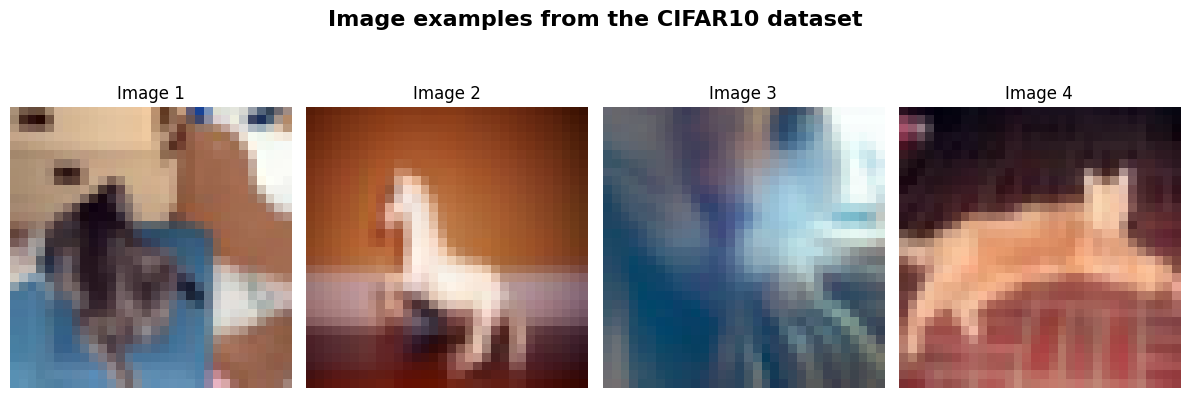

In [2]:
# Downloads CIFAR10 and create train/val/test loaders

test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])
# For training, we add some augmentation. Networks are too powerful and would overfit.
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                      transforms.RandomResizedCrop((32,32),scale=(0.8,1.0),ratio=(0.9,1.1)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.49139968, 0.48215841, 0.44653091], [0.24703223, 0.24348513, 0.26158784])
                                     ])
# Loading the training dataset. We need to split it into a training and validation part
# We need to do a little trick because the validation set should not use the augmentation.
train_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=train_transform, download=True)
val_dataset = CIFAR10(root=DATASET_PATH, train=True, transform=test_transform, download=True)
train_set, _ = torch.utils.data.random_split(train_dataset, [45000, 5000])
_, val_set = torch.utils.data.random_split(val_dataset, [45000, 5000])

# Loading the test set
test_set = CIFAR10(root=DATASET_PATH, train=False, transform=test_transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

# Visualize some examples
NUM_IMAGES = 4
CIFAR_images = torch.stack([val_set[idx][0] for idx in range(NUM_IMAGES)], dim=0)
fig, ax = plt.subplots(1, NUM_IMAGES, figsize=(12, 4))
fig.suptitle("Image examples from the CIFAR10 dataset", fontsize=16, fontweight='bold', y=1.05)
for i in range(NUM_IMAGES):
    img = CIFAR_images[i].permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    
    ax[i].imshow(img)
    ax[i].set_title(f"Image {i+1}", fontsize=12)
    ax[i].axis('off')

plt.tight_layout()
plt.savefig('images_cifar.png')
plt.show()
plt.close()

### Patchify
- Split $N\times N$ image into $(N/M)^2$ patches of size $M\times M$.
```python
    B, C, H, W = x.shape  # Batch size, Channels, Height, Width
    x = x.reshape(B, C, H//patch_size, patch_size, W//patch_size, patch_size)
```

<img src="images/images_cifar_patchify.png" alt="ml" style="width:80%; margin-left: auto; margin-right: auto;"/>

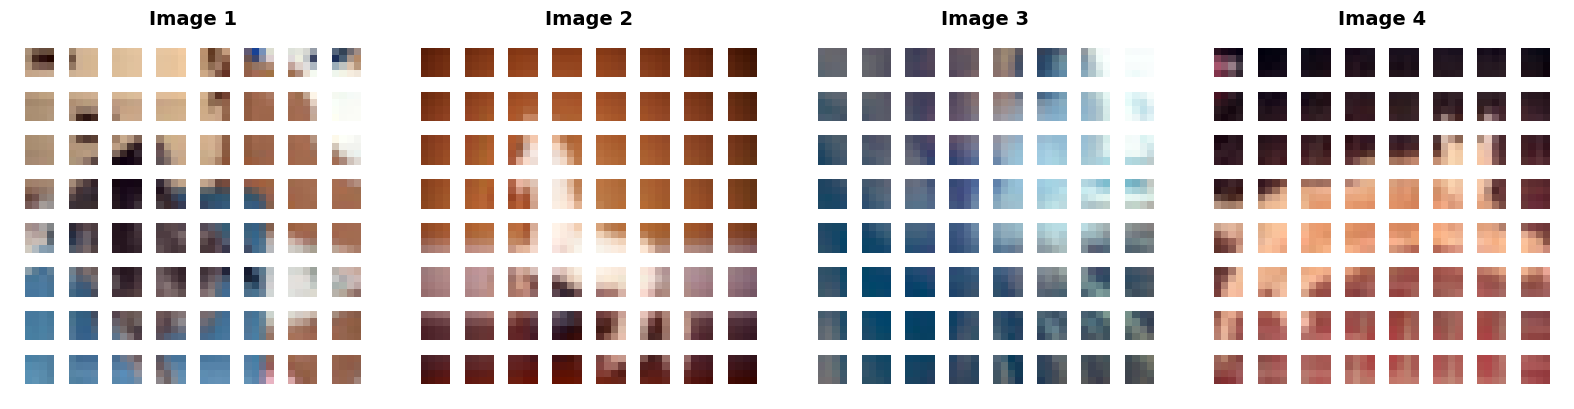

In [3]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - torch.Tensor representing the image of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H//patch_size, patch_size, W//patch_size, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5) # [B, H', W', C, p_H, p_W]
    x = x.flatten(1,2)              # [B, H'*W', C, p_H, p_W]
    if flatten_channels:
        x = x.flatten(2,4)          # [B, H'*W', C*p_H*p_W]
    return x

img_patches = img_to_patch(CIFAR_images, patch_size=4, flatten_channels=False)

fig, ax = plt.subplots(1, CIFAR_images.shape[0], figsize=(CIFAR_images.shape[0] * 4, 4))

# Handle cases where there might only be 1 image
if CIFAR_images.shape[0] == 1:
    ax = [ax]

for i in range(CIFAR_images.shape[0]):
    # Process the i-th image patches
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=8, normalize=True, pad_value=1)
    img_grid = img_grid.permute(1, 2, 0)
    
    ax[i].imshow(img_grid)
    
    # Set the title for each column
    ax[i].set_title(f"Image {i+1}", fontsize=14, fontweight='bold')
    
    # Clean up the axes
    ax[i].axis('off')

plt.tight_layout()
plt.savefig('images_cifar_patchify.png', bbox_inches='tight')
plt.show()
plt.close()

<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 60%; vertical-align: middle; padding-right: 20px;">
        <h3 style="margin-top: 0;">Self-attention</h3>
        <div style="font-size: 1.2em; padding: 15px; border-radius: 8px;">
            $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
        </div>
        <pre style="font-size: 1.1em;"><code class="language-python">def scaled_dot_product(q, k, v):
    # dot prod
    attn_logits = torch.matmul(q, k.transpose(-2, -1)) 
    # scaling
    attn_logits = attn_logits / math.sqrt(q.size()[-1])
    # softmax
    attention = F.softmax(attn_logits, dim=-1)         
    # dot prod
    values = torch.matmul(attention, v)                
    return values, attention</code></pre>
    </td>
    <td style="border: none; width: 40%; text-align: center; vertical-align: middle;">
        <img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/scaled_dot_product_attn.svg" alt="ml" style="width:60%; margin-left: auto; margin-right: auto;"/>
    </td>
  </tr>
</table>



**A different perspective for better understanding QKV**

QKV is used to mimic a *search-and-match* procedure to find how much two tokens in a sequence are relevant (the weights) and what is the context (the values). 
* Query (Q) acts as the current token's question: "What am I looking for?"
* Key (K) is the descriptor for each token: "What information do I have?"
* Value (V) is the actual content or information payload of the token.
  
Example

We want to search for more information on the self-attention mechanism (a Query) in a library. We ask the librarian whether she can retrieve some information for us. Each book is represented as a Key-Value pair where the Key is the title and the Value is the actual book content. The librarian compares your search Query with the Keys of all the books, measures the similarites and rank the results based on it. She then focuses on the content (Value) of those specific books to give you the answer you need.

<figure style="text-align: center;">
  <img src="images/qkv_example.png" alt="ml" style="width: 40%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Image generated with Nano Banana.
  </figcaption>
</figure>


In [4]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    attn_logits = torch.matmul(q, k.transpose(-2, -1))
    attn_logits = attn_logits / math.sqrt(d_k)
    if mask is not None:
        attn_logits = attn_logits.masked_fill(mask == 0, -9e15)
    attention = F.softmax(attn_logits, dim=-1)
    values = torch.matmul(attention, v)
    return values, attention

### Multi-head attention (simplified)

- We project the input to a high-dimensional space and we divide it into **multiple heads**. This allows different heads to focus on different features.
- We reshape the data by stacking the heads together, so that the self-attention processes all of them simultaneously.
- We concatenate the results from all heads before passing it to a linear layer that project it back to the original input dimension.


``` python        

    qkv = nn.Linear(input_dim, 3*embed_dim)(x) # project to embed_dim
    qkv = qkv.reshape(batch_size, seq_length, num_heads, 3*head_dim) # reshape by stacking the heads together
    q, k, v = qkv.chunk(3, dim=-1) 

    values, attention = scaled_dot_product(q, k, v, mask=mask) # self-attention
    values = values.reshape(batch_size, seq_length, embed_dim) # concatenate the results from all heads
    out = nn.Linear(embed_dim, input_dim) # project back to the original input_dim
```

In [5]:
def expand_mask(mask):
    assert mask.ndim >= 2, "Mask must be at least 2-dimensional with seq_length x seq_length"
    if mask.ndim == 3:
        mask = mask.unsqueeze(1)
    while mask.ndim < 4:
        mask = mask.unsqueeze(0)
    return mask

class MultiheadAttention(nn.Module):
    
    def __init__(self, input_dim, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "Embedding dimension must be 0 modulo number of heads."
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        # Stack all weight matrices 1...h together for efficiency
        # Note that in many implementations you see "bias=False" which is optional
        self.qkv_proj = nn.Linear(input_dim, 3*embed_dim)
        self.o_proj = nn.Linear(embed_dim, input_dim)
        
        self._reset_parameters()

    def _reset_parameters(self):
        # Original Transformer initialization, see PyTorch documentation
        nn.init.xavier_uniform_(self.qkv_proj.weight)
        self.qkv_proj.bias.data.fill_(0)
        nn.init.xavier_uniform_(self.o_proj.weight)
        self.o_proj.bias.data.fill_(0)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_length, _ = x.size()
        if mask is not None:
            mask = expand_mask(mask)
        qkv = self.qkv_proj(x)
        
        # Separate Q, K, V from linear output
        qkv = qkv.reshape(batch_size, seq_length, self.num_heads, 3*self.head_dim)
        qkv = qkv.permute(0, 2, 1, 3) # [Batch, Head, SeqLen, Dims]
        q, k, v = qkv.chunk(3, dim=-1)
        
        # Determine value outputs
        values, attention = scaled_dot_product(q, k, v, mask=mask)
        values = values.permute(0, 2, 1, 3) # [Batch, SeqLen, Head, Dims]
        values = values.reshape(batch_size, seq_length, self.embed_dim)
        o = self.o_proj(values)
        
        if return_attention:
            return o, attention
        else:
            return o

<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 60%; vertical-align: middle; padding-right: 20px;">
        <h3 style="margin-top: 0;">Attention block</h3>
        <pre style="font-size: 1.1em;"><code class="language-python">def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):    
    self.layer_norm_1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim, num_heads)
    self.layer_norm_2 = nn.LayerNorm(embed_dim)
    self.linear = nn.Sequential( # Feed-forward layer
        nn.Linear(embed_dim, hidden_dim),
        nn.GELU(), nn.Dropout(dropout),
        nn.Linear(hidden_dim, embed_dim),
        nn.Dropout(dropout)
    )
    </code></pre>
    <pre style="font-size: 1.1em;"><code class="language-python">def forward(self, x):
    inp_x = self.layer_norm_1(x)
    x = x + self.attn(inp_x, inp_x, inp_x)[0] # self-att + res
    x = x + self.linear(self.layer_norm_2(x)) # feed-fw + res
    return x</code></pre>        
    </td>
    <td style="border: none; width: 40%; text-align: center; vertical-align: middle;">
        <img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_attention_layer.png" alt="ml" style="width:80%; margin-left: auto; margin-right: auto;"/>
    </td>
  </tr>
</table>


Note: There are usually multiple attention blocks, or layers. At the beginning of the ViT, the tokens will be representative of patches in the input image. However, deeper attention layers will compute attention on tokens that have been modified by preceding layers.

In [13]:
class AttentionBlock(nn.Module):
    
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors
            hidden_dim - Dimensionality of hidden layer in feed-forward network 
                         (usually 2-4x larger than embed_dim)
            num_heads - Number of heads to use in the Multi-Head Attention block
            dropout - Amount of dropout to apply in the feed-forward network
        """
        super().__init__()
        
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, 
                                          dropout=dropout)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
        
        
    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0] # self-attn + res
        x = x + self.linear(self.layer_norm_2(x)) # self-attn + res
        return x

## Completing the ViT implementation

Final steps: 
- Linear patch embeddings to map image patches to D-dimensional vectors
- Add classification token to the input sequence
- 2D positional encoding so the model understands the spatial layout of the patches
- A small MLP head to map [CLS] token to prediction

<figure style="text-align: center;">
  <img src="images/vit.png" alt="ml" style="width: 50%">
</figure>


### Positional encoding
- We implement this pattern and run it across a 2D grid:
$$
PE_{(pos,i)} = \begin{cases}
    \sin\left(\frac{pos}{10000^{i/d_{\text{model}}}}\right) & \text{if}\hspace{3mm} i \text{ mod } 2=0\\
    \cos\left(\frac{pos}{10000^{(i-1)/d_{\text{model}}}}\right) & \text{otherwise}\\
\end{cases}
$$
where $p$ is the index of the token in the sequence and $i$ represents the index in the embedding vector, and $d_{model}$ is the embedding dimension of the model.

<figure style="text-align: center;">
  <img src="images/positional_encodings.png" alt="ml" style="width: 50%">
</figure>


**Why using sinusoidals?**

If we use simple integers the values could get massive for long sequences and the model would not be able to generalize to sequence lengths it hasn't seen before.

Sinusoidals have some important characteristics: 
- each position in the sequence has a unique encoding
- periodic patterns ensure that similar positions have similar encodings
- easily differentiable, hence suited for backpropagation during training
- allows models to handle any sequence length

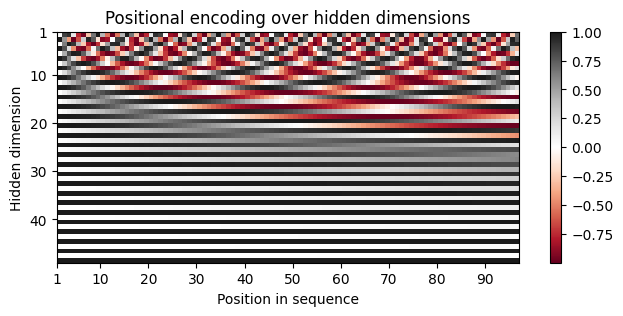

In [14]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        """
        Inputs
            d_model - Hidden dimensionality of the input.
            max_len - Maximum length of a sequence to expect.
        """
        super().__init__()

        # Create matrix of [SeqLen, HiddenDim] representing the positional encoding for max_len inputs
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        # register_buffer => Tensor which is not a parameter, but should be part of the modules state.
        # Used for tensors that need to be on the same device as the module.
        # persistent=False tells PyTorch to not add the buffer to the state dict (e.g. when we save the model) 
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x
    
encod_block = PositionalEncoding(d_model=48, max_len=96)
pe = encod_block.pe.squeeze().T.cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,3))
pos = ax.imshow(pe, cmap="RdGy", extent=(1,pe.shape[1]+1,pe.shape[0]+1,1))
fig.colorbar(pos, ax=ax)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Hidden dimension")
ax.set_title("Positional encoding over hidden dimensions")
ax.set_xticks([1]+[i*10 for i in range(1,1+pe.shape[1]//10)])
ax.set_yticks([1]+[i*10 for i in range(1,1+pe.shape[0]//10)])
plt.savefig('positional_encodings.png', bbox_inches='tight')
plt.show()

<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 60%; vertical-align: middle; padding-right: 20px;">
        <h3 style="margin-top: 0;">Forward pass of ViT</h3>
        <pre style="font-size: 1.1em;"><code class="language-python">
        def forward(self, x):
            # Preprocess input (patchify)
            x = img_to_patch(x, self.patch_size)
            B, T, _ = x.shape
            x = self.input_layer(x)
            # Add CLS token and positional encoding
            cls_token = self.cls_token.repeat(B, 1, 1)
            x = torch.cat([cls_token, x], dim=1)
            x = x + self.pos_embedding[:,:T+1]
            # Apply Transformer (with multiple layers)
            x = self.dropout(x)
            x = x.transpose(0, 1)
            x = self.transformer(x)
            # Perform classification prediction
            cls = x[0]
            return self.mlp_head(cls)
            </code></pre>  
    </td>
    <td style="border: none; width: 40%; text-align: center; vertical-align: middle;">
        <img src="images/vit_screenshot.png" alt="ml" style="width:100%;"/>
    </td>
  </tr>
</table>



In [15]:
class VisionTransformer(nn.Module):
    
    def __init__(self, embed_dim, hidden_dim, num_channels, num_heads, num_layers, num_classes, patch_size, num_patches, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of the input feature vectors to the Transformer
            hidden_dim - Dimensionality of the hidden layer in the feed-forward networks
                         within the Transformer
            num_channels - Number of channels of the input (3 for RGB)
            num_heads - Number of heads to use in the Multi-Head Attention block
            num_layers - Number of layers to use in the Transformer
            num_classes - Number of classes to predict
            patch_size - Number of pixels that the patches have per dimension
            num_patches - Maximum number of patches an image can have
            dropout - Amount of dropout to apply in the feed-forward network and 
                      on the input encoding
        """
        super().__init__()
        
        self.patch_size = patch_size
        
        # Layers/Networks
        self.input_layer = nn.Linear(num_channels*(patch_size**2), embed_dim)
        self.transformer = nn.Sequential(*[AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)
        
        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1,1+num_patches,embed_dim))
    
    
    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape
        x = self.input_layer(x)
        
        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embedding[:,:T+1]
        
        # Apply Transforrmer
        x = self.dropout(x)
        x = x.transpose(0, 1)
        x = self.transformer(x)
        
        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

In [16]:
class ViT(pl.LightningModule):
    
    def __init__(self, model_kwargs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(**model_kwargs)
        self.example_input_array = next(iter(train_loader))[0]
        
    def forward(self, x):
        return self.model(x)
    
    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr)
        lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100,150], gamma=0.1)
        return [optimizer], [lr_scheduler]   
    
    def _calculate_loss(self, batch, mode="train"):
        imgs, labels = batch
        preds = self.model(imgs)
        loss = F.cross_entropy(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()
        
        self.log(f'{mode}_loss', loss)
        self.log(f'{mode}_acc', acc)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._calculate_loss(batch, mode="train")
        return loss

    def validation_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="val")

    def test_step(self, batch, batch_idx):
        self._calculate_loss(batch, mode="test")

In [17]:
def train_model(**kwargs):
    trainer = pl.Trainer(default_root_dir=os.path.join(CHECKPOINT_PATH, "ViT"), 
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",
                         devices=1,
                         max_epochs=180,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),
                                    LearningRateMonitor("epoch")])
    trainer.logger._log_graph = True         # If True, we plot the computation graph in tensorboard
    trainer.logger._default_hp_metric = None # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, "ViT", "ViT.ckpt")
    if os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = ViT.load_from_checkpoint(pretrained_filename) # Automatically loads the model with the saved hyperparameters
    else:
        pl.seed_everything(42) # To be reproducable
        model = ViT(**kwargs)
        print("Train model from scratch...")
        trainer.fit(model, train_loader, val_loader)
        model = ViT.load_from_checkpoint(trainer.checkpoint_callback.best_model_path) # Load best checkpoint after training

    # Test best model on validation and test set
    print("Test model")
    val_result = trainer.test(model, val_loader, verbose=False)
    test_result = trainer.test(model, test_loader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result

In [18]:
os.path.join(CHECKPOINT_PATH, "ViT")

'./data/checkpoints\\ViT'

In [ ]:
model, results = train_model(model_kwargs={
                                'embed_dim': 256,
                                'hidden_dim': 512,
                                'num_heads': 8,
                                'num_layers': 6,
                                'patch_size': 4,
                                'num_channels': 3,
                                'num_patches': 64,
                                'num_classes': 10,
                                'dropout': 0.2
                            },
                            lr=3e-4)
print("ViT results", results)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42


Train model from scratch...



  | Name  | Type              | Params | Mode  | FLOPs  | In sizes         | Out sizes
--------------------------------------------------------------------------------------------
0 | model | VisionTransformer | 3.2 M  | train | 55.9 B | [128, 3, 32, 32] | [128, 10]
--------------------------------------------------------------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.781    Total estimated model params size (MB)
73        Modules in train mode
0         Modules in eval mode
55.9 B    Total Flops


Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\20234803\Desktop\Postdoc\Courses\MLE_2026\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\20234803\Desktop\Postdoc\Courses\MLE_2026\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
C:\Users\20234803\Desktop\Postdoc\Courses\MLE_2026\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

### Results
* ResNet outperforms ViT on CIFAR-10
* Inductive biases of CNNs win out if you have limited data/compute
* Transformers have very little inductive bias
    * More flexible, but also more data hungry
<figure style="text-align: center;">
  <img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_resnetvit.png" alt="ml" style="width: 50%">
</figure>

# Attention visualization

It helps visualizing which parts of an image the model focuses on for the final prediction. 

Looking at a single layer is not sufficient , but we need to aggregate the attention maps from multiple layers to have a comprehensive view, which is called **attention rollout**.

<figure style="text-align: center;">
  <img src="images/attention_visualization.png" alt="ml" style="width: 60%">
</figure>

Step 1: Average the attention maps from all heads ($h$) of each layer ($l$).
$$
\bar{A}^l = \frac{1}{H} \sum_h A^{hl}
$$
Step 2: Add the identity matrix ($I$) to correct for the residual connection.
$$
\hat{A}^l = 0.5\bar{A}^l + 0.5I,
$$
Step 3: For the actual rollout we multiply the attention matrices from each layer sequentially.
$$
R = \prod_{i=1}^L \hat{A}^l
$$
Step 4: We then look at the attention rollout corresponding to the [CLS] token.

```python
# --- Compute Rollout ---
# Start with the attention matrix of the first layer
rollout = attentions[0]

# Iterate through the remaining layers
for i in range(1, len(attentions)):
    attn = attentions[i]
    
    # Step 2: Add the residual connection (Identity matrix)
    # The formula is: 0.5 * I + 0.5 * Attention
    id_matrix = torch.eye(rollout.shape[0])
    attn_residual = 0.5 * torch.eye(rollout.shape[0]) + 0.5 * attn
    
    # Step 3: Multiply
    rollout = torch.matmul(attn_residual, rollout)

# Extract the attention of the CLS token (row 0) to all patches
cls_attention = rollout[0]
# Discard the CLS token's attention to itself (index 0) to get only patch attention
cls_attention = cls_attention[1:]

```
<figure style="text-align: center;">
  <img src="images/attn_rollout.png" alt="ml" style="width: 40%">
</figure>


Computing Attention Rollout...


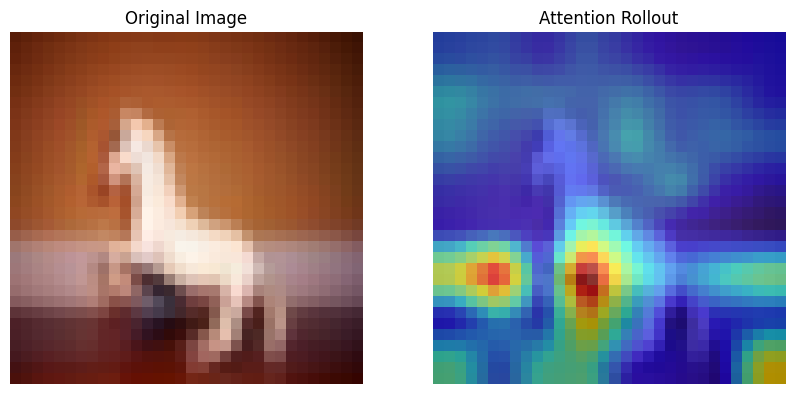

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def get_attention_rollout(model, img_tensor, device="cpu"):
    """
    Computes the attention rollout for a single image.
    
    Args:
        model: The trained ViT model (LightningModule).
        img_tensor: The input image tensor (C, H, W).
        device: The device the model is on.
        
    Returns:
        rollout_map: A numpy array of shape (H, W) representing the attention.
    """
    model.eval()
    model = model.to(device)
    img_tensor = img_tensor.to(device)
    
    # List to store attention matrices from each layer
    attentions = []

    # Define a hook function to capture attention weights
    def get_attention_hook(module, input, output):
        # nn.MultiheadAttention returns (attn_output, attn_weights)
        attn_weights = output[1]

        # Step 1: Average attention maps from multiple heads (if needed)
        if attn_weights.dim() == 3:
            # Shape: (Batch, Seq_Len, Seq_Len) - Heads already averaged
            attn_weights = attn_weights[0] # Take first batch
        elif attn_weights.dim() == 4:
            # Shape: (Batch, Heads, Seq_Len, Seq_Len) - We need to average over the heads
            attn_weights = attn_weights[0].mean(dim=0)
        attentions.append(attn_weights.detach().cpu())

    # Register forward hooks on the MultiheadAttention modules inside each AttentionBlock
    handles = []
    vit_model = model.model 
    
    for block in vit_model.transformer:
        # block is an AttentionBlock, block.attn is nn.MultiheadAttention
        handle = block.attn.register_forward_hook(get_attention_hook)
        handles.append(handle)

    # Perform a forward pass
    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0))

    # Remove hooks
    for handle in handles:
        handle.remove()

    # --- Compute Rollout ---
    # Start with the attention matrix of the first layer
    rollout = attentions[0]
    
    # Iterate through the remaining layers
    for i in range(1, len(attentions)):
        attn = attentions[i]
        
        # Step 2: Add the residual connection (Identity matrix)
        # The formula is: 0.5 * I + 0.5 * Attention
        id_matrix = torch.eye(rollout.shape[0])
        attn_residual = 0.5 * torch.eye(rollout.shape[0]) + 0.5 * attn
        
        # Step 3: Multiply
        rollout = torch.matmul(attn_residual, rollout)

    # Extract the attention of the CLS token (row 0) to all patches
    cls_attention = rollout[0]
    # Discard the CLS token's attention to itself (index 0) to get only patch attention
    cls_attention = cls_attention[1:]
    
    return cls_attention.numpy()

def visualize_rollout(img_tensor, rollout_map, patch_size):
    """
    Visualizes the original image and the attention rollout heatmap.
    """
    # 1. Process the image for display
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    # Denormalize/Scale for visualization
    img = (img - img.min()) / (img.max() - img.min())
    
    # 2. Reshape rollout map to the patch grid
    num_patches = rollout_map.shape[0]
    h_patches = int(np.sqrt(num_patches))
    w_patches = int(np.sqrt(num_patches))
    
    attention_grid = rollout_map.reshape(h_patches, w_patches)
    
    # 3. Resize heatmap to original image size
    from torchvision import transforms
    
    # FIX: Convert NumPy array to PyTorch Tensor first
    attention_grid_tensor = torch.from_numpy(attention_grid).float()
    
    # Normalize the heatmap to 0-1 range for better visualization
    # (Rollout values can be very small depending on depth)
    attention_grid_tensor = (attention_grid_tensor - attention_grid_tensor.min()) / \
                            (attention_grid_tensor.max() - attention_grid_tensor.min() + 1e-8)
    
    # Add Channel dimension: (H, W) -> (1, H, W) expected by ToPILImage
    attention_grid_tensor = attention_grid_tensor.unsqueeze(0)
    
    resize_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((img.shape[0], img.shape[1])),
        transforms.ToTensor()
    ])
    
    # Apply transform
    heatmap_tensor = resize_transform(attention_grid_tensor).squeeze()
    heatmap_np = heatmap_tensor.numpy()

    # 4. Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')
    
    ax[1].imshow(img)
    # Overlay heatmap
    ax[1].imshow(heatmap_np, cmap='jet', alpha=0.6)
    ax[1].set_title("Attention Rollout")
    ax[1].axis('off')
    plt.savefig("attn_rollout.png", bbox_inches='tight')
    
    plt.show()

# Pick a random image from the test set
img = CIFAR_images[1]
label = model(img.unsqueeze(0)) 

print(f"Computing Attention Rollout...")
rollout_map = get_attention_rollout(model, img, device=next(model.parameters()).device)

# Visualize
visualize_rollout(img, rollout_map, patch_size=model.model.patch_size)

# Multimodal models with vision and text

<figure style="text-align: center;">
  <img src="images/mllms.png" alt="ml" style="width: 50%">
</figure>

Let's look at an example.

<figure style="text-align: center;">
  <img src="images/example_mllms.png" alt="ml" style="width: 80%">
</figure>

And there are many more, for instance mathematical reasoning with an image plot, web agents with webpage screenshot, etc.

# Contrastive Language-Image Pre-Training (CLIP)

Goal: training a model to learn a good image representation.

Idea: Learn from images and text jointly without label supervision.
- Learn an image encoder $f_I(x_I) \rightarrow z_I$.
- Learn a text encoder $f_T(x_T) \rightarrow z_T$.
- Force the representations for an image and corresponding text to be close together.
- Force the representations for an image and an unpaired text to be far apart.

Given N (image, text) pairs, classify which image is paired with which text.

<figure style="text-align: center;">
  <img src="images/clip.png" alt="ml" style="width: 60%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2103.00020" target="_blank">Learning Transferable Visual Models From Natural Language Supervision (Radford et al.)</a>
  </figcaption>
</figure>

<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 50%; vertical-align: middle; padding-right: 5px;">
        <ul style="line-height: 1.5; font-size: 1.1em;">
        <strong>Training loss for CLIP</strong>
        <img src="images/loss_clip.png" style="width: 100%;">
        </ul>
    </td>
    <td style="border: none; width: 50%; text-align: center;">
        <ul style="line-height: 1.5; font-size: 1.1em;">
        <strong>Pseudocode for training loss</strong>
        <img src="images/code_clip.png" style="width: 100%;">
        <br><small>Source: <a href="https://arxiv.org/pdf/2103.00020" target="_blank">Learning Transferable Visual Models From Natural Language Supervision (Radford et al.)</a></small>
        </ul>
    </td>
  </tr>
</table>

**Zero-shot classification**

After the training phase you end up with a good pre-traines text and image encoder and you can use them for zero-shot classification (without any additional examples).

<figure style="text-align: center;">
  <img src="images/zero-shot-clip.png" alt="ml" style="width: 60%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2103.00020" target="_blank">Learning Transferable Visual Models From Natural Language Supervision (Radford et al.)</a>
  </figcaption>
</figure>


Let's look at the Python code!

```python
from transformers import CLIPProcessor, CLIPModel

# Load model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32") # wraps an image processor and a tokenizer
print("CLIP model loaded successfully!")

# Load image from COCO dataset
url = "https://farm1.staticflickr.com/166/343915369_895049d44f_z.jpg"
image = Image.open(requests.get(url, stream=True).raw)
```

<figure style="text-align: center;">
  <img src="images/giraffe.jpg" alt="ml" style="width: 30%">
</figure>

```python
# Define text descriptions
texts = ["a photo of a giraffe", "a photo of a horse"]

# Process inputs
inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)

# Get model outputs
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # image-text similarity scores
probs = logits_per_image.softmax(dim=1)  # convert to probabilities

# Display results
print("Giraffe vs Horse Classification")

# Most likely
max_idx = probs[0].argmax().item()
print(f"\nPrediction: {texts[max_idx]} ({probs[0][max_idx].item():.1%})")

```
<figure style="text-align: center;">
  <img src="images/clip_classification.png" alt="ml" style="width: 30%">
</figure>

# Llava: Large Language and Vision Assistant

A language model (LLM) that takes in input images and text. 
The idea is to project the "image tokens" to the embedding space of the text tokens and fine-tuning the model with image-text data.

<table style="border: none; width: 100%; border-collapse: collapse;">
  <tr style="border: none;">
    <td style="border: none; width: 50%; vertical-align: middle; padding-right: 5px;">
        <ul style="line-height: 1.5; font-size: 1.1em;">
        Step 1: <strong>Image preprocessing</strong> by splitting the image into patches and vectorize them.<br><br>
        Step 2: <strong>Image encoding</strong> using a pre-trained transformer model (e.g., CLIP) and extracting the vectors from the last layer.<br><br>
        Step 3: <strong>Pass the encodings to the LLM</strong> after projecting them in the space of the text tokens, with a simple MLP.<br><br>
        Step 4: <strong>Train/Fine-tune</strong> on data with text and images. The objective is always next-token predictions computed on the output text tokens.
        </ul>
    </td>
    <td style="border: none; width: 50%; text-align: center;">
        <img src="images/llava.png" style="width: 100%;">
    </td>
  </tr>
</table>

Comparison between Llava, GPT-4 and BLIP-2 (a model inspired from CLIP).

<figure style="text-align: center;">
  <img src="images/llava_example.png" alt="ml" style="width: 70%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2304.08485" target="_blank">Visual Instruction Tuning (Liu et al.)</a>
  </figcaption>
</figure>

# Text generation models with other modalities

In [2]:
from IPython.display import Video

Video("images/pi0.mp4", width=750, height=500)

### Vision-Language Action Models (VLAs)

<figure style="text-align: center;">
  <img src="images/openvla.png" alt="ml" style="width: 80%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2406.09246" target="_blank">OpenVLA (Kim et al.)</a>
  </figcaption>
</figure>

### Video-Language Models (VLMs)

<figure style="text-align: center;">
  <img src="images/qwen3-vl.png" alt="ml" style="width: 80%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2511.21631" target="_blank">Qwen3-VL Technical Report (Qwen Team)</a>
  </figcaption>
</figure>


An example

<figure style="text-align: center;">
  <img src="images/example_qwen3.png" alt="ml" style="width: 80%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://huggingface.co/spaces/Qwen/Qwen3-VL-Demo" target="_blank">Hugging Face space (Qwen/Qwen3-VL-Demo)</a>
  </figcaption>
</figure>


## Audio-Text-to-Text Models

<figure style="text-align: center;">
  <img src="images/voxtral.png" alt="ml" style="width: 100%">
    <figcaption style="font-size: 0.9em; color: gray; margin-top: 5px;">
    Source: <a href="https://arxiv.org/pdf/2507.13264" target="_blank">Voxtral (Mistral.AI)</a>
  </figcaption>
</figure>

Examples of use cases:
- Audio QA: ask questions about lectures, podcasts, or calls and get context-aware answers.
- Meeting notes & action items: turn multi-speaker meetings into concise minutes with decisions, owners, and deadlines.
- Speech understanding & intent: extract information about the speech and the intent, sentiment, uncertainty, or emotion from spoken language.
- Music & sound analysis: describe instrumentation, genre, tempo, or sections and suggest edits.

**And many more, such as tabular-text models, timeseries-text models, etc.**


But, remember that we only focused on Multi-to-text in this lecture. More can be done when generating also images, videos, etc.
<figure style="text-align: center;">
  <img src="images/mllms.png" alt="ml" style="width: 40%">
</figure>

# What's next?

<figure style="text-align: center;">
  <img src="images/native-vs-modula-vlms.png" alt="ml" style="width: 80%">
</figure>

Check the following papers to learn more:
* Team, Chameleon. "Chameleon: Mixed-modal early-fusion foundation models." arXiv preprint arXiv:2405.09818 (2024).
* Sun, Quan, et al. "Emu: Generative pretraining in multimodality." arXiv preprint arXiv:2307.05222 (2023).

# Useful material

- Ebrahim Pichka. [What is Query, Key, and Value (QKV) in the Transformer Architecture and Why Are They Used?](https://epichka.com/blog/2023/qkv-transformer/) (2023).
- Sebastian Raschka. [Understanding Multimodal LLMs](https://magazine.sebastianraschka.com/p/understanding-multimodal-llms). (November 2024)
- Stanford CS231n course. [Deep Learning for Computer Vision](https://cs231n.stanford.edu/). (Spring 2025).
- CMU course. [Advanced Natural Language Processing](https://cmu-l3.github.io/anlp-spring2025/). (Spring 2025).
- Samira Abnar. [Quantifying Attention Flow in Transformers](https://samiraabnar.github.io/articles/2020-04/attention_flow). (Spring 2020).
- Jacob Gildenblat. [Exploring Explainability for Vision Transformers](https://jacobgil.github.io/deeplearning/vision-transformer-explainability)
- Liu, Haotian, et al. "Visual instruction tuning." Advances in neural information processing systems 36 (2023).
- Bai, Shuai, et al. "Qwen3-vl technical report." arXiv preprint arXiv:2511.21631 (2025).
- Liu, Alexander H., et al. "Voxtral." arXiv preprint arXiv:2507.13264 (2025).